## Dynamika różniczkowa
Konrad Słotta 277442

### Metoda wstecznych różniczkowań (backward differentiation formula BDF) rzędu 2
Metoda BDF2 (ang. Backward Differentiation Formula of second order, pol. metoda wstecznego różniczkowania drugiego rzędu) należy do rodziny niejawnych metod wielokrokowych stosowanych do numerycznego rozwiązywania równań różniczkowych zwyczajnych. Metoda wykorzystuje wartości rozwiązania z poprzednich kroków czasowych do aproksymacji pochodnej w chwili bieżącej. W przypadku BDF2 pochodna jest przybliżana na podstawie dwóch wcześniejszych punktów siatki czasowej, co zapewnia dokładność drugiego rzędu. Metoda BDF2 ma postać
$$
y_{n+2} - \frac{4}{3}y_{n+1} + \frac{1}{3}y_n = \frac{2}{3}hf(t_{n+2}, y_{n+2}).
$$
Poniżej przedstawiono implementację tej metody w Julii.

In [2]:
using LinearAlgebra
using DifferentialEquations
using Plots

Funkcja `bdf2` przyjmuje następujące argumenty
- `f(t, y)` :
    Funkcja opisująca prawą stronę układu równań:
    ``y' = f(t, y)``.

- `Jf(t, y)` :
    Jakobian funkcji `f` względem zmiennej `y`.

- `y0` :
    Wektor warunków początkowych.

- `t0` :
    Początkowy czas symulacji.

- `t_end` :
    Końcowy czas symulacji.

- `h` :
    Krok czasowy.

- `tol=1e-10` :
    Tolerancja zbieżności metody Newtona.

- `max_iter=20` :
    Maksymalna liczba iteracji Newtona w pojedynczym kroku.

Zwraca
- `t` :
    Wektor punktów czasowych.

- `y` :
    Wektor rozwiązań numerycznych.
    Każdy element `y[i]` jest wektorem stanu układu
    w chwili `t[i]`.

Metoda BDF2 jest metodą dwukrokową, zatem konieczne jest wcześniejsze wyznaczenie drugiego punktu siatki czasowej `y[2]`. W implementacji został on obliczony przy pomocy metody Rungego-Kutty drugiego rzędu. W kolejnych krokach stosowana jest niejawna metoda BDF2 opisana wyżej. Ponieważ niewiadoma wartość $y_{n+2}$ występuje po obu stronach równania, w każdym kroku konieczne jest rozwiązanie układu nieliniowego. W tym celu zastosowano metodę Newtona, która iteracyjnie poprawia przybliżenie rozwiązania aż do spełnienia zadanego kryterium dokładności `tol`.

In [3]:
function bdf2(f::Function, Jf::Function, y0::Vector{Float64}, t0::Float64, t_end::Float64, h::Float64; tol::Float64=1e-10, max_iter::Int=20)

    t = t0:h:t_end
    n_steps = length(t)

    m = length(y0)
    y = [zeros(m) for _ in 1:n_steps]

    y[1] .= y0

    k1 = f(t[1], y[1])
    k2 = f(t[1] + h, y[1] + h*k1)
    y[2] .= y[1] + (h/2)*(k1 + k2)

    for n in 3:n_steps

        y_new = copy(y[n-1])

        for k in 1:max_iter

            F = 1.5*y_new - 2y[n-1] + 0.5*y[n-2] - h*f(t[n], y_new)

            J = 1.5*I - h*Jf(t[n], y_new)

            Δ = J \ F

            y_next = y_new - Δ

            if norm(Δ) < tol
                y_new = y_next
                break
            end

            y_new = y_next
        end

        y[n] = y_new
    end

    return t, y
end

bdf2 (generic function with 1 method)

Najważniejszą zaletą metod typu BDF jest bardzo dobra stabilność numeryczna. Metody te są szczególnie skuteczne dla układów sztywnych, czyli takich, w których występują jednocześnie bardzo szybkie i bardzo wolne skale czasowe. W przypadku metod jawnych wymagałoby to stosowania bardzo małych kroków czasowych w celu zachowania stabilności, natomiast metoda BDF2 pozwala stosować znacznie większe kroki bez utraty stabilności rozwiązania. Ta własność zostanie pokazana na poniższym przykładzie.

## Przykład zastosowania
Rozważmy układ równań
$$
\begin{cases}
x' = -x \\
y' = -1000y + 1000x
\end{cases}
$$
gdzie $x = x(t)$ oraz  $y = y(t)$ są zmiennymi zależnymi od czasu $t$. Dodatkowo, przyjmujemy $x(0) = y(0) = 1$. Układ ten zostanie rozwiązany powyższą funkcją bdf2. Następnie rozwiązanie zostanie porównane z rozwiązaniem analitycznym oraz wbudowanym solverem z pakietu `DifferentialEquations.jl`.

In [4]:
f(t, y) = [
    -y[1],
    -1000*y[2] + 1000*y[1]
]

dfdy(t, y) = [
    -1.0  0.0;
    1000.0  -1000.0
]

y0 = [1.0, 1.0]
t0 = 0.0
t_end = 5.0

5.0

Rozwiązanie analityczne układu równań przy $x(0) = y(0) = 1$ wygląda następująco
$$
\begin{cases}
x(t) = e^{-t} \\
y(t) = \frac{1000}{999}e^{-t}-\frac{1}{999}e^{-1000t}
\end{cases}
$$

Układ ten jest przykładem układu sztywnego, ponieważ występują w nim dwie bardzo różne skale czasowe. Zmienna $x(t)$ zmienia się powoli, natomiast $y(t)$ zawiera składnik $e^{−1000t}$, który zanika bardzo szybko już na początku symulacji. Powoduje to występowanie gwałtownej warstwy przejściowej na początku rozwiązania oraz bardzo szybkiej relaksacji do stanu zależnego głównie od wolnej skali czasowej.

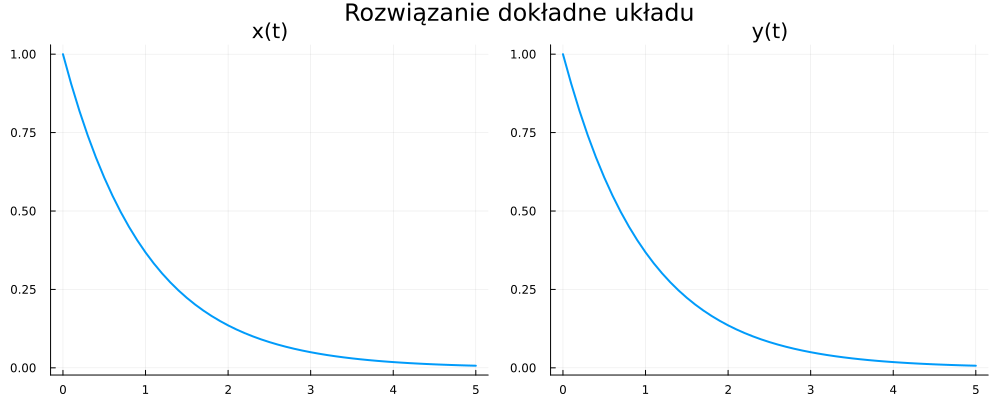

In [5]:
x_exact(t) = exp.(-t)

y_exact(t) = (1000/999) .* exp.(-t) .- (1/999) .* exp.(-1000 .* t)

h = 0.1

plots = []


t = t0:h:t_end

x = x_exact(t)
y = y_exact(t)

p1 = plot(t, x, label="", lw=2, title="x(t)")

p2 = plot(t, y, label="", lw=2, title="y(t)")

push!(plots, p1)
push!(plots, p2)


plot(plots..., layout=(1,2), size=(1000,400), plot_title = "Rozwiązanie dokładne układu")

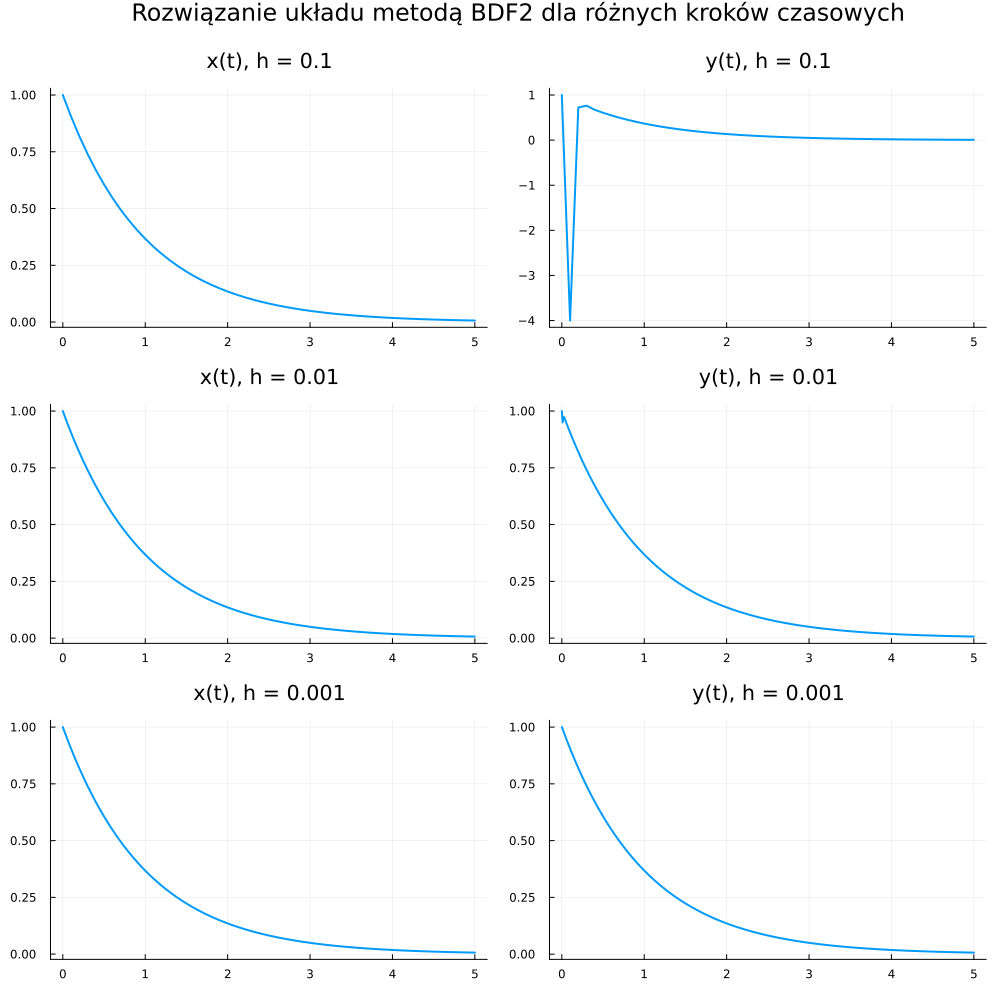

In [12]:
hs = [0.1, 0.01, 0.001]

plots = []

for h in hs

    t, result = bdf2(f, dfdy, y0, t0, t_end, h)

    x = first.(result)
    y = last.(result)
    p1 = plot(t, x, label="", lw=2,
              title="x(t), h = $h")

    p2 = plot(t, y, label="", lw=2,
              title="y(t), h = $h")

    push!(plots, p1)
    push!(plots, p2)
end

plot(plots..., layout=(3,2), size=(1000,1000), plot_title = "Rozwiązanie układu metodą BDF2 dla różnych kroków czasowych")

Analiza uzyskanych wyników potwierdza, że metoda BDF2 skutecznie radzi sobie z wysoką sztywnością układu dzięki swoim właściwościom stabilnościowym. Wyraźnie widoczny dla kroku $h=0.1$ błąd w fazie początkowej wynika z ograniczeń jawnej metody startowej (RK2), jednak charakterystyczna dla BDF2 silna zdolność do tłumienia zaburzeń pozwala na błyskawiczny powrót rozwiązania do właściwej trajektorii. Wraz ze zmniejszaniem kroku czasowego do poziomu $h=0.001$, faza przejściowa ulega pełnemu wygładzeniu, a wyniki wykazują wysoką zgodność z rozwiązaniem analitycznym. Dowodzi to, że zaimplementowany schemat uwikłany zachowuje stabilność numeryczną nawet w warunkach, w których klasyczne metody jawne uległyby rozbieżności.

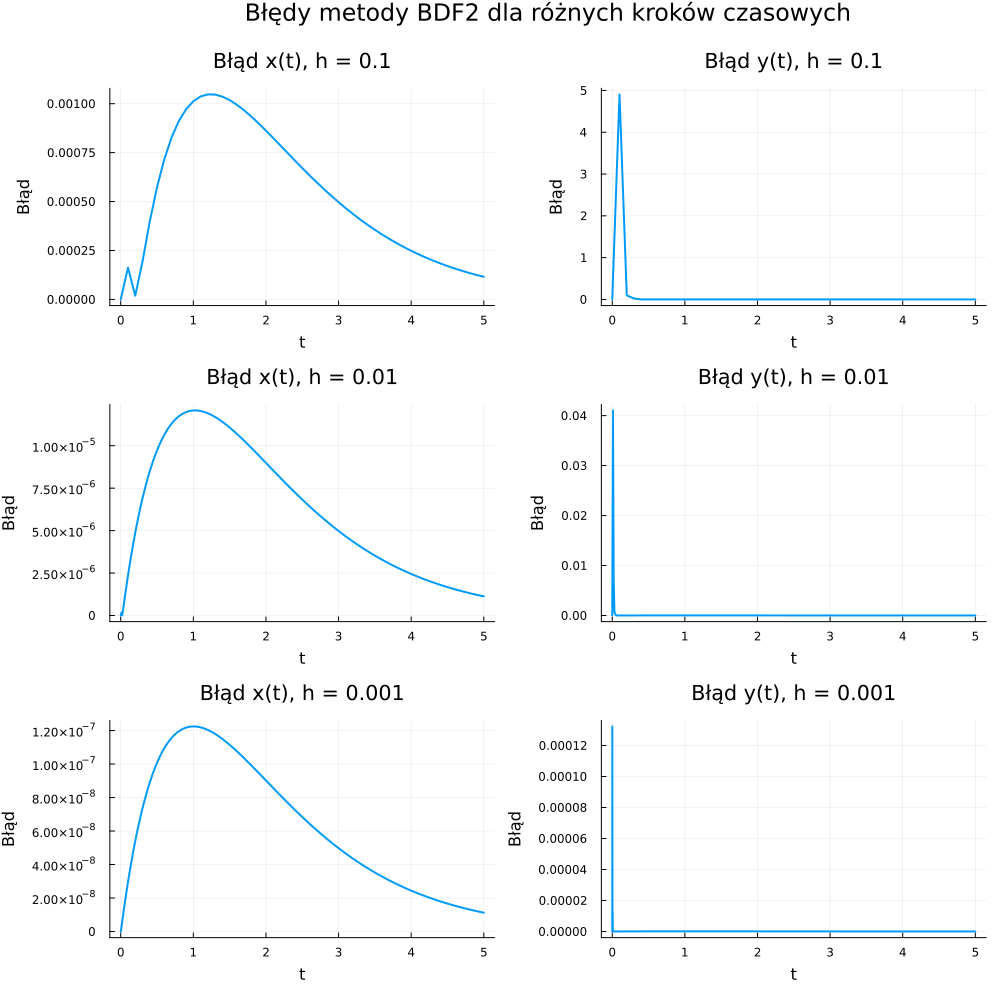

In [ ]:
hs = [0.1, 0.01, 0.001]

plots = []

for h in hs

    t, result = bdf2(f, dfdy, y0, t0, t_end, h)

    x_num = first.(result)
    y_num = last.(result)

    x_ex = x_exact(t)
    y_ex = y_exact(t)

    err_x = abs.(x_num .- x_ex)
    err_y = abs.(y_num .- y_ex)

    p1 = plot(t, err_x, label = "", lw = 2, title = "Błąd x(t), h = $h", xlabel = "t", ylabel = "Błąd")

    p2 = plot(t, err_y, label = "", lw = 2, title = "Błąd y(t), h = $h", xlabel = "t", ylabel = "Błąd")

    push!(plots, p1)
    push!(plots, p2)

end

plot(plots..., layout = (3,2), size = (1000,1000), plot_title = "Błędy metody BDF2 dla różnych kroków czasowych")

Na wykresach przedstawiono błędy bezwzględne rozwiązania numerycznego względem rozwiązania analitycznego. Wraz ze zmniejszaniem kroku czasowego h obserwowany jest wyraźny spadek błędu, co potwierdza zbieżność metody BDF2. Największe błędy pojawiają się w początkowej fazie rozwiązania, gdzie układ wykazuje najszybsze zmiany związane ze sztywnością problemu. Wysoki skok błędu w drugim kroku czasowym jest wynikiem przybliżenia metodą RK2.

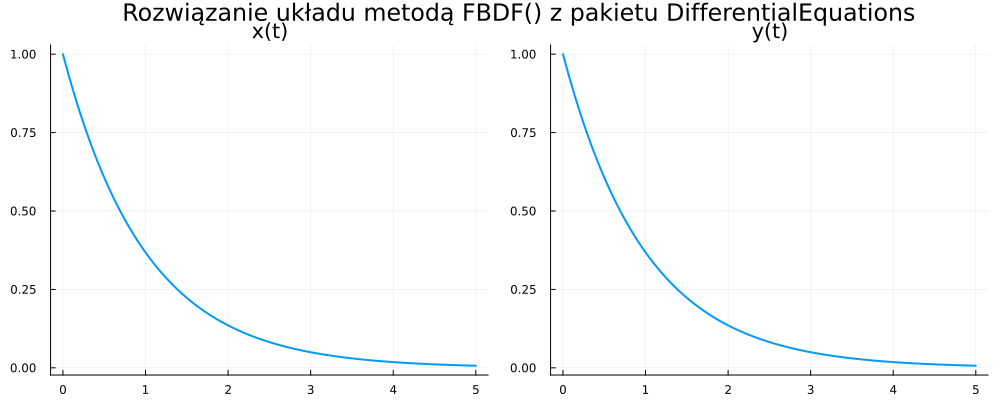

In [32]:
function f_builtin!(du, u, p, t)

    du[1] = -u[1]
    du[2] = -1000*u[2] + 1000*u[1]

end

u0 = [1.0, 1.0]

tspan = (0.0, 5.0)

prob = ODEProblem(f_builtin!, u0, tspan)

sol = solve(prob, FBDF(), reltol=1e-10, abstol=1e-10)

x = first.(sol.u)
y = last.(sol.u)
t = sol.t

plots = []
p1 = plot(t, x, label="", lw=2, title="x(t)")

p2 = plot(t, y, label="", lw=2, title="y(t)")

push!(plots, p1)
push!(plots, p2)

plot(plots..., layout=(1,2), size=(1000,400), plot_title = "Rozwiązanie układu metodą FBDF() z pakietu DifferentialEquations")

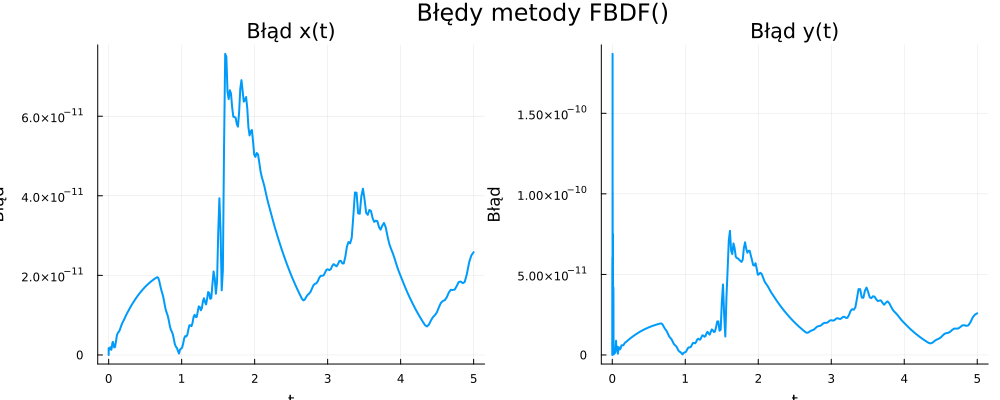

In [33]:
plots = []
h = 0.001
u0 = [1.0, 1.0]
t = t0:h:t_end
tspan = (0.0, 5.0)

prob = ODEProblem(f_builtin!, u0, tspan)

sol = solve(prob, FBDF(), reltol=1e-10, abstol=1e-10)

x_num = first.(sol.u)
y_num = last.(sol.u)
t = sol.t

x_ex = x_exact(t)
y_ex = y_exact(t)

err_x = abs.(x_num .- x_ex)
err_y = abs.(y_num .- y_ex)

p1 = plot(t, err_x, label = "", lw = 2, title = "Błąd x(t)", xlabel = "t", ylabel = "Błąd")

p2 = plot(t, err_y, label = "", lw = 2, title = "Błąd y(t)", xlabel = "t", ylabel = "Błąd")

push!(plots, p1)
push!(plots, p2)

plot(plots..., layout = (1,2), size = (1000,400), plot_title = "Błędy metody FBDF()")

Funkcja biblioteczna `FBDF()` z pakietu `DifferentialEquations.jl` implementuje adaptacyjną metodę wstecznych różniczkowań (Backward Differentiation Formula), przeznaczoną do rozwiązywania sztywnych układów równań różniczkowych zwyczajnych. W przeciwieństwie do własnej implementacji BDF2, funkcja biblioteczna automatycznie dobiera krok czasowy oraz rząd metody. Porównanie otrzymanych wykresów pokazuje, że wyniki uzyskane za pomocą własnej implementacji BDF2 są zgodne z rozwiązaniem wyznaczonym przez `FBDF()`. Świadczy to o poprawności implementacji własnego solwera. Analiza błedów natomiast przy zachowaniu tego samego poziomu tolerancji, wykazała istotną przewagę funkcji bibliotecznej `FBDF()` nad własną implementacją. Wynika to z adaptacyjnego doboru kroku czasowego oraz możliwości automatycznej zmiany rzędu metody, co pozwala efektywniej kontrolować błąd numeryczny.